In [1]:
%matplotlib widget
from importlib import reload
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
file = '../2025_airglow_response/data/profile_VCD_for_scaling_pd.csv'
profile = pd.read_csv(file)
profile.columns

Index(['altitude', 'p', 't', ' W-E wind component (m/s)',
       ' S-N wind component (m/s)', 'c', 'rho',
       ' atmospheric heat capacity Cp (J/kg/K) ', 'gamma',
       ' atmospheric viscosity estimation (N/s/m2)',
       ' CO2 volume mixing ratio (mol/mol)',
       ' N2 volume mixing ratio (mol/mol)',
       ' H2O volume mixing ratio (mol/mol)'],
      dtype='object')

In [12]:
from scipy import interpolate
f_c = interpolate.interp1d(profile.altitude.values/1e3, profile.c.values)
f_w = interpolate.interp1d(profile.altitude.values/1e3, profile[' W-E wind component (m/s)'].values)

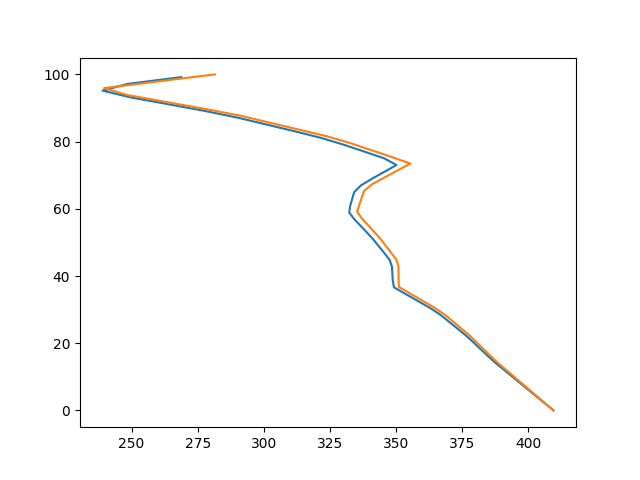

In [14]:
R = 6081
r = np.linspace(0., 100., 50)
h_f = R*np.log((R+r)/R)
c_f_base = (R/(R+r))*f_c(r)
f_c_f_base = interpolate.interp1d(r, c_f_base)
w_f_base = (R/(R+r))*f_w(r)
f_w_f_base = interpolate.interp1d(r, w_f_base)
c_f = f_c_f_base(h_f) + f_w_f_base(h_f)

plt.figure()
plt.plot(c_f, h_f)
plt.plot(f_c(r)+f_w(r), r)